# Índice

>[Metodologia](#scrollTo=TsaKjv73Y8A-)

>[Dataset: Rice Cammeo and Osmancik](#scrollTo=UDXWHV08l76Q)

>>[Análise exploratória](#scrollTo=1KUe_AhVnAB1)

>>[Tratamento dos Dados](#scrollTo=elLWWv9-hqPI)

>>[Aplicação dos classificadores](#scrollTo=kSyf4YAtl3Hj)

>>>[Ajustando parâmetros para KNN e Decision Tree](#scrollTo=fNZhzZEtz4Z2)

>>>[Aplicando os melhores parâmetros](#scrollTo=PkEjMQ3dAsvI)

>>[Resultados](#scrollTo=L8FRTgKT5exU)

>>[Discussão](#scrollTo=AzDO1yLL5jNS)

>[Dataset: Letter Recognition](#scrollTo=uTd4774BKVqQ)

>>[Análise exploratória](#scrollTo=9eQQKhqqLGUQ)

>>[Tratamento dos dados](#scrollTo=9Eb6cEs_MTxg)

>>[Aplicação dos classificadores](#scrollTo=-DzH9mGjUWmO)

>>>[Ajustando parâmetros para KNN e Decision Tree](#scrollTo=SpTgMXOCUt3P)

>>>[Aplicando os melhores parâmetros](#scrollTo=V50LfTI8WHiO)

>>[Resultados](#scrollTo=0JBCh7Z4Wb0q)

>>[Discussão](#scrollTo=iRIKMN4ibUuP)

>[Dataset: Glass Identification](#scrollTo=teqMtD0Yl1bJ)

>>[Análise exploratória](#scrollTo=lNGdhpW-20QJ)

>>[Tratamento dos dados](#scrollTo=h16mHDSYr3Vc)

>>[Aplicação dos classificadores](#scrollTo=E_W1MWhusnuk)

>>>[Ajustando parâmetros de KNN e Decision Tree](#scrollTo=FjoRIKbTsuxb)

>>>[Aplicando os melhores parâmetros](#scrollTo=4wWyrxSDtCWd)

>>[Resultados](#scrollTo=NlfZQ4DYtmpk)

>>[Discussão](#scrollTo=0-AS-CSLvlI0)



# Introdução
Neste trabalho, realizamos uma análise comparativa de desempenho de diferentes modelos de classificação em uma variedade de datasets obtidos do UC Irvine Machine Learning Repository. Os datasets utilizados foram: Iris, Wine, Breast Cancer Wisconsin, Spambase, Parkinsons, Phishing Websites, Predict Student Dropout, Rice Cammeo and Osmancik, Letter Recognition e Glass Identification.

Os modelos utilizados para o treinamento e teste dos dados foram K-Nearest Neighbors (KNN), Árvore de Decisão e Naive Bayes. Cada um desses modelos possui características distintas que os tornam adequados para diferentes tipos de problemas de classificação.

- K-Nearest Neighbors (KNN): Este modelo é baseado no princípio de que objetos semelhantes estão próximos uns dos outros. Ele classifica um novo ponto de dados com base na maioria dos votos de seus 'k' vizinhos mais próximos no espaço dos dados.
- Árvore de Decisão: Este modelo usa uma estrutura de árvore para tomar decisões baseadas em perguntas que dividem os dados em subconjuntos cada vez menores. As árvores de decisão são intuitivas e fáceis de interpretar.
- Naive Bayes: Este é um modelo probabilístico baseado no Teorema de Bayes, que assume independência entre os atributos. Apesar da suposição simplificadora, o Naive Bayes frequentemente performa bem em diversos problemas de classificação.

Para garantir a robustez e a generalização dos modelos, utilizamos o método de validação cruzada K-Fold na separação dos dados. Esse método divide o conjunto de dados em 'k' subconjuntos ou "folds". Em cada iteração, um fold é utilizado como conjunto de teste e os 'k-1' folds restantes são utilizados para treinamento. Esse processo é repetido 'k' vezes, de forma que cada fold seja utilizado uma vez como conjunto de teste. Finalmente, os resultados são agregados para obter uma medida mais confiável do desempenho do modelo.

A seguir, apresentamos uma análise detalhada dos resultados obtidos com cada um dos modelos nos diferentes datasets, destacando as métricas de desempenho e as particularidades de cada caso.

# Metodologia

Para a realização deste trabalho, utilizamos diversas bibliotecas populares de Python para manipulação e análise de dados, visualização de gráficos e aplicação de modelos de classificação. Os pacotes necessários foram instalados previamente e incluem:
- `pandas`: Utilizado para manipulação e análise de dados;
- `numpy`: utilizado para suporte a arrays e matrizes;
- `seaborn`: utilizado para visualização de dados baseada em matplotlib;
- `matplotlib`: utilizado para criar gráficos 2D em Python;
- Scikit-learn (`sklearn`): biblioteca fundamental para utilizar os modelos de classificação em Python, contendo ferramentas simples e eficientes para análise de dados e modelagem preditiva;
- `ucimlrepo`: todos os 10 conjuntos de dados utilizados neste notebook foram importados do UC Irvine Machine Learning Repository.

A seguir, apresentamos o código para a instalação dos pacotes necessários e a importação dos módulos que foram utilizados ao longo da análise.

In [ ]:
!pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import model_selection
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
import matplotlib.pyplot as plt

Para a análise dos dados, utilizamos dois componentes principais de cada dataset:

- `dataset_data`: Este componente contém as características (features) ou atributos dos dados que serão usados como entrada para os modelos de classificação. Cada linha representa uma amostra e cada coluna representa uma característica.
- `dataset_target`: Este componente contém as classes ou rótulos (labels) que correspondem às amostras em dataset_data. Cada entrada corresponde ao rótulo da amostra na mesma posição em dataset_data.

Depois de importar cada um dos _datasets_, a análise exploratória exibe metadados e tabelas sobre o conjunto de dados importado conforme a função `explore`.

In [ ]:
def explore(dataset_nome, dataset_data, dataset_target):
  '''
  Função para realizar a análise exploratória dos dados.
  Parâmetros: String dataset_nome, pandas dataframe dataset_data e dataset_target.
  '''
  print(f"Informações sobre o dataset {dataset_nome}:\n")
  display(dataset_data.info())

  print(f"\nDescrição das classes do dataset {dataset_nome}:\n")
  display(dataset_target.describe())

  print(f"\nDescrição dos dados do dataset {dataset_nome}:\n")
  display(dataset_data.describe())

  print(f"\nPrimeiros valores do dataset {dataset_nome}:\n")
  dataset_combined = pd.concat([dataset_data, dataset_target], axis=1)
  display(dataset_combined.head())

  print(f"\nDescrição dos valores distintos dos dados:\n")
  display(dataset_data.nunique())

  print(f"\nDescrição dos valores distintos das classes:\n")
  display(dataset_target.nunique())

  if not dataset_data.isnull().values.any():
    print(f"\nNão há valores nulos no dataset {dataset_nome}.")
  else:
     print(f"\nHá valores nulos no dataset {dataset_nome}.")

  duplicated_data = dataset_combined[dataset_combined.duplicated()]
  if duplicated_data.empty:
      print(f"\nNão há dados duplicados no dataset {dataset_nome}.")
  else:
      print(f"\nHá {len(duplicated_data)} linhas duplicadas no dataset {dataset_nome}:\n")
      display(duplicated_data)


O dataset é normalizado com a função normalize_dataset.

In [ ]:
def normalize_dataset(dataset_data,dataset_target):
  '''
  Função para normalizar o dataset.
  Parâmetros: pandas dataframe dataset_data e dataset_target)
  '''
  scaler = MinMaxScaler()
  scaler.fit(dataset_data)
  dataset_normalized = scaler.transform(dataset_data)
  dataset_target_numpy = dataset_target.to_numpy()
  dataset_combined = pd.concat([pd.DataFrame(dataset_normalized), pd.DataFrame(dataset_target_numpy)], axis=1)
  display(dataset_combined.head())
  return dataset_normalized, np.ravel(dataset_target_numpy)

Os melhores parâmetros para os modelos utilizados em que o ajuste é aplicável (KNN e Decision Tree) são obtidos com a função get_best_params.

In [ ]:
def get_best_params(dataset_data_normalized,dataset_targets_normalized, outer_kf,neighbors_list,tree_depth_list):
  '''
  Função para obter os melhores parâmetros para o KNN e Decision Tree.
  Retorna dicionario com os melhores parâmetros de cada modelo.
  Parâmetros:
  dataset_data_normalized: dados normalizados
  dataset_targets_normalized: dados de classe normalizados
  outer_kf: kfolds que serão utilizados para ajustar os parametros
  neighbors_list: lista de números de vizinhos que serão testados no KNN
  tree_depth_list: lista de profundidades de árvores que serão testados em Decision Tree
  '''
  knn = KNeighborsClassifier()
  param_dist = {'n_neighbors':neighbors_list,'weights':['uniform','distance']}
  grid_search = GridSearchCV(knn, param_grid=param_dist,cv=outer_kf,scoring='accuracy',refit=False)
  grid_search.fit(dataset_data_normalized,dataset_targets_normalized)
  knn_best_params = grid_search.best_params_
  print(f"Melhores parâmetros para KNN: {knn_best_params}\n\n")

  decision_tree = tree.DecisionTreeClassifier()
  param_dist = {'max_depth':tree_depth_list}
  grid_search = GridSearchCV(decision_tree,param_grid=param_dist,cv=outer_kf,scoring='accuracy',refit=False)
  grid_search.fit(dataset_data_normalized,dataset_targets_normalized)
  decision_tree_best_params = grid_search.best_params_
  print(f"Melhores parâmetros para Decision Tree: {decision_tree_best_params}\n\n")
  return knn_best_params, decision_tree_best_params

O dicionário com os resultados das classes preditas é obtido com a função generate_predicted_classes_str.

In [ ]:
def generate_predicted_classes_str(dataset_target) -> dict:
  '''
  Função para gerar o dicionario que contém os resultados.
  Aplicável quando classes target são strings.
  '''
  predicted_classes = dict()
  empty_vector = np.full(dataset_target.shape[0], '', dtype='<U10')
  predicted_classes['tree'] = empty_vector.copy()
  predicted_classes['knn'] = empty_vector.copy()
  predicted_classes['naive'] = empty_vector.copy()
  return predicted_classes

A aplicação dos modelos para os diferentes k-folds ocorre em get_predicted_classes_str.

In [ ]:
def get_predicted_classes_str(dataset_data_normalized,dataset_targets_normalized, knn_best_params, decision_tree_best_params, inner_kf):
  '''
  Função para obter um dicionário com as predições para cada um dos três modelos escolhidos.
  Parâmetros:
  dataset_data_normalized: dados normalizados
  dataset_targets_normalized: dados de classe normalizados
  knn_best_params: melhores parâmetros do KNN
  decision_tree_best_params: melhores parâmetros de Decision Tree
  inner_kf: kfolds que serão utilizados para o treinamento dos modelos
  '''
  knn = KNeighborsClassifier(**knn_best_params)
  decision_tree = tree.DecisionTreeClassifier(**decision_tree_best_params)
  naive_bayes = GaussianNB()
  predicted_classes = generate_predicted_classes_str(dataset_targets_normalized)

  all_tree_predictions = np.empty(dataset_targets_normalized.shape, dtype=dataset_targets_normalized.dtype)
  all_knn_predictions = np.empty(dataset_targets_normalized.shape, dtype=dataset_targets_normalized.dtype)
  all_naive_predictions = np.empty(dataset_targets_normalized.shape, dtype=dataset_targets_normalized.dtype)

  for train, test in inner_kf.split(dataset_data_normalized,dataset_targets_normalized):
    data_train, target_train = dataset_data_normalized[train],dataset_targets_normalized[train]
    data_test, target_test = dataset_data_normalized[test], dataset_targets_normalized[test]

    decision_tree = decision_tree.fit(data_train,target_train)
    decision_tree_predicted = decision_tree.predict(data_test)
    all_tree_predictions[test] = decision_tree_predicted

    knn.fit(data_train, target_train)
    knn_predicted=knn.predict(data_test)
    all_knn_predictions[test] = knn_predicted

    naive_bayer = naive_bayes.fit(data_train,target_train)
    naive_predicted = naive_bayer.predict(data_test)
    all_naive_predictions[test] = naive_predicted

  predicted_classes['tree'] = all_tree_predictions
  predicted_classes['knn'] = all_knn_predictions
  predicted_classes['naive'] = all_naive_predictions
  return predicted_classes

Um dicionário com as métricas para plotagem de gráficos é obtido com a função get_metrics_dict.

In [ ]:
def get_metrics_dict(dataset_targets_normalized):
  '''
  Função que retorna um dicionário metrics_dict pra plotagem.
  '''
  metrics_dict = {
      'Precision': [
          metrics.precision_score(dataset_targets_normalized, predicted_classes['tree'],average='weighted'),
          metrics.precision_score(dataset_targets_normalized, predicted_classes['knn'],average='weighted'),
          metrics.precision_score(dataset_targets_normalized, predicted_classes['naive'],average='weighted')
      ],
      'Recall': [
          metrics.recall_score(dataset_targets_normalized, predicted_classes['tree'],average='weighted'),
          metrics.recall_score(dataset_targets_normalized, predicted_classes['knn'],average='weighted'),
          metrics.recall_score(dataset_targets_normalized, predicted_classes['naive'],average='weighted')
      ],
      'F1 Score': [
          metrics.f1_score(dataset_targets_normalized, predicted_classes['tree'],average='weighted'),
          metrics.f1_score(dataset_targets_normalized, predicted_classes['knn'],average='weighted'),
          metrics.f1_score(dataset_targets_normalized, predicted_classes['naive'],average='weighted')
      ],
      'Accuracy': [
          metrics.accuracy_score(dataset_targets_normalized, predicted_classes['tree']),
          metrics.accuracy_score(dataset_targets_normalized, predicted_classes['knn']),
          metrics.accuracy_score(dataset_targets_normalized, predicted_classes['naive'])
      ]
    }
  return metrics_dict

A função plot_metrics mostra uma comparação das métricas dos classificadores.

In [ ]:
def plot_metrics(metrics_dict, classifier_names):
    metrics_df = pd.DataFrame(metrics_dict, index=classifier_names)
    metrics_df.plot(kind='bar', figsize=(12, 8))
    plt.title('Comparação das métricas de classificadores')
    plt.ylabel('Score')
    plt.xlabel('Classificadores')
    plt.xticks(rotation=0)
    plt.show()

A função plot_confusion_matrix mostra a matriz de confusão obtida com o classificador.

In [ ]:
def plot_confusion_matrix(y_true, y_pred, classifier_name):
    cm = metrics.confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.title(f'Matriz de Confusão - {classifier_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Dataset: Rice Cammeo and Osmancik

Este dataset trata de tipos de arroz cultivados na Turquia, das espécies Osmancik e Cammeo, que foram selecionadas para o estudo. Os integrantes da espécie Osmancik possuem aparência larga, longa, vítrea e opaca. Os integrantes da espécie Cammeo possuem as mesmas características. Um total de 3810 imagens de grão de arroz foram tiradas para as duas espécies e feitas inferências de características. Foram obtidas 7 características morfológicas para cada grão de arroz.

## Análise exploratória
Importação do dataset Rice Cammeo and Osmancik

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
rice_cammeo_and_osmancik = fetch_ucirepo(id=545)

# data (as pandas dataframes)
rice_data = rice_cammeo_and_osmancik.data.features
rice_targets = rice_cammeo_and_osmancik.data.targets

# metadata
print(rice_cammeo_and_osmancik.metadata)

# variable information
print(rice_cammeo_and_osmancik.variables)

{'uci_id': 545, 'name': 'Rice (Cammeo and Osmancik)', 'repository_url': 'https://archive.ics.uci.edu/dataset/545/rice+cammeo+and+osmancik', 'data_url': 'https://archive.ics.uci.edu/static/public/545/data.csv', 'abstract': "A total of 3810 rice grain's images were taken for the two species, processed and feature inferences were made. 7 morphological features were obtained for each grain of rice.", 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 3810, 'num_features': 7, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5MW4Z', 'creators': [], 'intro_paper': {'title': 'Classification of Rice Varieties Using Artificial Intelligence Methods', 'authors': 'Ilkay Cinar, M. Koklu', 'published_in': 'International Journal of Intelligent Systems and App

In [ ]:
explore(dataset_nome="Rice Cammeo and Osmancik", dataset_data=rice_data,dataset_target=rice_targets)

Informações sobre o dataset Rice Cammeo and Osmancik:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 208.5 KB


None


Descrição das classes do dataset Rice Cammeo and Osmancik:



,Class
count,3810
unique,2
top,Osmancik
freq,2180



Descrição dos dados do dataset Rice Cammeo and Osmancik:



...


Descrição dos valores distintos dos dados:



Area                 2828
Perimeter            3738
Major_Axis_Length    3808
Minor_Axis_Length    3804
Eccentricity         3803
Convex_Area          2857
Extent               3804
dtype: int64


Descrição dos valores distintos das classes:



Class    2
dtype: int64


Não há valores nulos no dataset Rice Cammeo and Osmancik.

Não há dados duplicados no dataset Rice Cammeo and Osmancik.


Os dados possuem duas classes (Cammeo e Osmancik), não possuem valores nulos ou duplicados.

## Tratamento dos Dados
Os dados são normalizados e mostrados na tabela abaixo.

In [ ]:
rice_data_normalized, rice_targets_normalized = normalize_dataset(rice_data, rice_targets)

,0,1,2,3,4,5,6,0
0,0.675937,0.879232,0.901216,0.532417,0.888011,0.693917,0.207577,Cammeo
1,0.625330,0.714095,0.648087,0.670663,0.691980,0.646009,0.324564,Cammeo
2,0.623394,0.750066,0.734349,0.588124,0.789846,0.635636,0.538576,Cammeo
3,0.495071,0.524136,0.512800,0.581461,0.671227,0.496220,0.393954,Cammeo
4,0.628146,0.781992,0.709138,0.620288,0.758067,0.662711,0.408680,Cammeo


## Aplicação dos classificadores

### Ajustando parâmetros para KNN e Decision Tree
Para o k-fold utilizado no ajuste de parâmetros, são divididos em 4 folds, e para utilização na aplicação dos modelos, 10 folds.

In [ ]:
inner_kf = model_selection.StratifiedKFold(n_splits=15, shuffle=True, random_state=None)
outer_kf = model_selection.StratifiedKFold(n_splits=4, shuffle=True, random_state=None)

knn_best_params, decision_tree_best_params = get_best_params(rice_data_normalized,rice_targets_normalized,outer_kf,
                                                             list(np.arange(1,15)),[3,4,5,6,7,8,9,10])

Melhores parâmetros para KNN: {'n_neighbors': 14, 'weights': 'distance'}


Melhores parâmetros para Decision Tree: {'max_depth': 4}




### Aplicando os melhores parâmetros
O dicionário python com as classes preditas é obtido e mostrado no bloco de código abaixo.

In [ ]:
predicted_classes = get_predicted_classes_str(dataset_data_normalized=rice_data_normalized,dataset_targets_normalized=rice_targets_normalized,
                                              knn_best_params=knn_best_params,decision_tree_best_params=decision_tree_best_params,
                                              inner_kf=inner_kf)
predicted_classes

{'tree': array(['Cammeo', 'Cammeo', 'Cammeo', ..., 'Osmancik', 'Osmancik',
        'Osmancik'], dtype=object),
 'knn': array(['Cammeo', 'Cammeo', 'Cammeo', ..., 'Osmancik', 'Osmancik',
        'Osmancik'], dtype=object),
 'naive': array(['Cammeo', 'Cammeo', 'Cammeo', ..., 'Osmancik', 'Osmancik',
        'Osmancik'], dtype=object)}

## Resultados
As informações de métricas e matrizes de confusão para cada classificador são mostrados no código, assim como a comparação dos classificadores.

Resultados do classificador tree
              precision    recall  f1-score   support

      Cammeo       0.92      0.90      0.91      1630
    Osmancik       0.92      0.94      0.93      2180

    accuracy                           0.92      3810
   macro avg       0.92      0.92      0.92      3810
weighted avg       0.92      0.92      0.92      3810





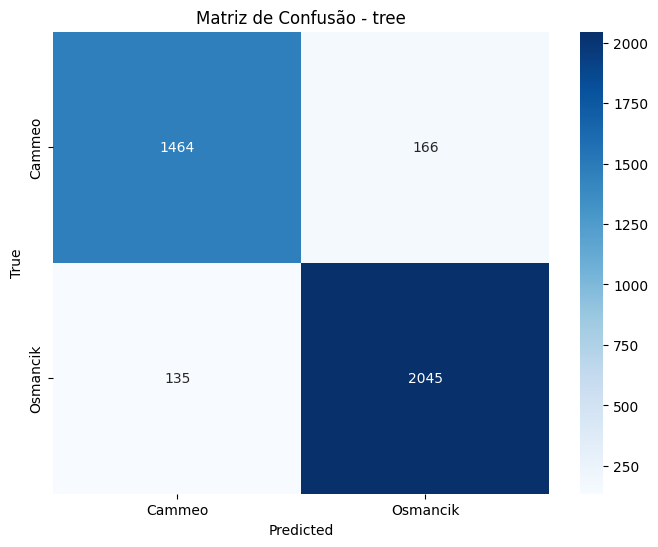

Resultados do classificador knn
              precision    recall  f1-score   support

      Cammeo       0.92      0.91      0.91      1630
    Osmancik       0.93      0.94      0.94      2180

    accuracy                           0.93      3810
   macro avg       0.93      0.92      0.93      3810
weighted avg       0.93      0.93      0.93      3810





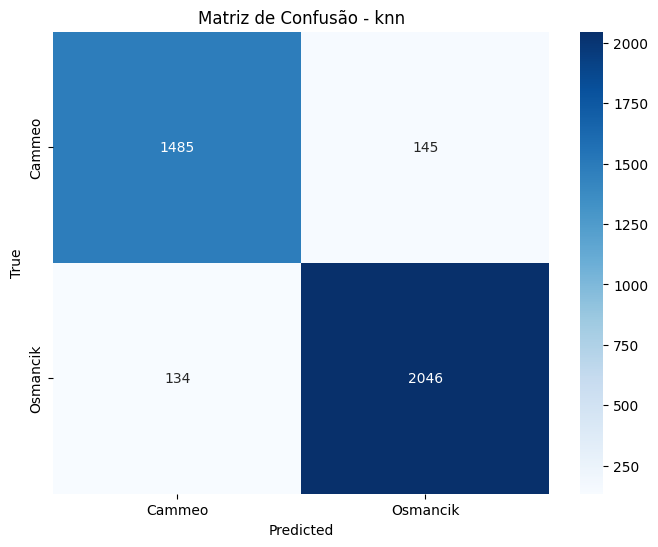

Resultados do classificador naive
              precision    recall  f1-score   support

      Cammeo       0.91      0.90      0.90      1630
    Osmancik       0.92      0.93      0.93      2180

    accuracy                           0.92      3810
   macro avg       0.92      0.91      0.91      3810
weighted avg       0.92      0.92      0.92      3810





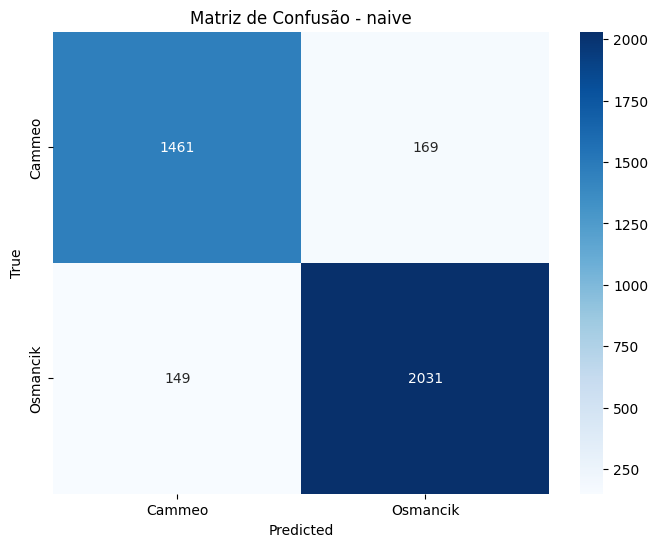

Gráfico de comparação das métricas de classificadores:


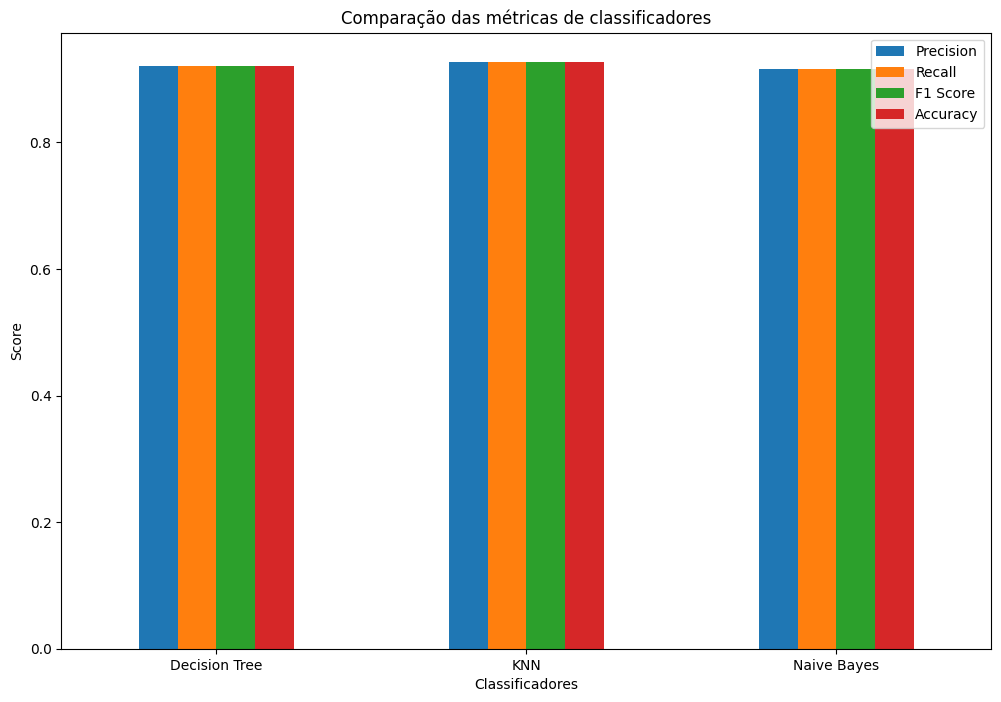

In [ ]:
for classifier in predicted_classes.keys():
  if classifier == 'knn':
    title_classifier = 'KNN'
  if classifier == 'tree':
    title_classifier = 'Decision Tree'
  if classifier == 'naive':
    title_classifier = 'Naive Bayes'
  print(f"Resultados do classificador {classifier}\n{metrics.classification_report(rice_targets_normalized,predicted_classes[classifier])}\n\n")
  plot_confusion_matrix(rice_targets_normalized,predicted_classes[classifier],classifier)

metrics_dict=get_metrics_dict(rice_targets_normalized)
print("Gráfico de comparação das métricas de classificadores:")
plot_metrics(metrics_dict=metrics_dict, classifier_names=['Decision Tree', 'KNN','Naive Bayes'])

## Discussão

Todos os três classificadores escolhidos (árvore de decisão, KNN e Naive Bayes) tem uma precisão, recall, e F1-Score muito semelhantes, com valores muito próximos entre si, com uma acurácia total de 0,92. Árvore de decisão e KNN mostram desempenho praticamente igual, com pouca vantagem para KNN em termos de menos erros na classe "Cammeo". Naive Bayes apresenta uma precisão e recall um pouco inferior para a classe "Osmancik". Se o foco é minimizar erros na classe "Osmancik", a árvore de decisão deve ser escolhida, mas se for minimizar erros na classe "Cammeo", KNN é a melhor escolha.

# Dataset: Letter Recognition
O dataset consiste em descrições de pixels retangulares em preto e branco com uma das 26 letras do alfabeto. As imagens foram baseadas em 20 fontes diferentes e cada letra dentro das fontes foi distorcida aleatoriamente.

## Análise exploratória
Importação do dataset Letter Recognition

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
letter_recognition = fetch_ucirepo(id=59)

# data (as pandas dataframes)
letter_recognition_data = letter_recognition.data.features
letter_recognition_targets = letter_recognition.data.targets

# metadata
print(letter_recognition.metadata)

# variable information
print(letter_recognition.variables)

{'uci_id': 59, 'name': 'Letter Recognition', 'repository_url': 'https://archive.ics.uci.edu/dataset/59/letter+recognition', 'data_url': 'https://archive.ics.uci.edu/static/public/59/data.csv', 'abstract': 'Database of character image features; try to identify the letter', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 20000, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['lettr'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1991, 'last_updated': 'Thu Sep 28 2023', 'dataset_doi': '10.24432/C5ZP40', 'creators': ['David Slate'], 'intro_paper': None, 'additional_info': {'summary': 'The objective is to identify each of a large number of black-and-white rectangular pixel displays as one of the 26 capital letters in the English alphabet.  The character images were based on 20 different fonts and each letter within these 20 fonts wa

In [ ]:
explore("Letter Recognition",letter_recognition_data,letter_recognition_targets)

Informações sobre o dataset Letter Recognition:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x-box   20000 non-null  int64
 1   y-box   20000 non-null  int64
 2   width   20000 non-null  int64
 3   high    20000 non-null  int64
 4   onpix   20000 non-null  int64
 5   x-bar   20000 non-null  int64
 6   y-bar   20000 non-null  int64
 7   x2bar   20000 non-null  int64
 8   y2bar   20000 non-null  int64
 9   xybar   20000 non-null  int64
 10  x2ybr   20000 non-null  int64
 11  xy2br   20000 non-null  int64
 12  x-ege   20000 non-null  int64
 13  xegvy   20000 non-null  int64
 14  y-ege   20000 non-null  int64
 15  yegvx   20000 non-null  int64
dtypes: int64(16)
memory usage: 2.4 MB


None


Descrição das classes do dataset Letter Recognition:



,lettr
count,20000
unique,26
top,U
freq,813



Descrição dos dados do dataset Letter Recognition:



...

x-box    16
y-box    16
width    16
high     16
onpix    16
x-bar    16
y-bar    16
x2bar    16
y2bar    16
xybar    16
x2ybr    16
xy2br    16
x-ege    16
xegvy    16
y-ege    16
yegvx    16
dtype: int64


Descrição dos valores distintos das classes:



lettr    26
dtype: int64


Não há valores nulos no dataset Letter Recognition.

Há 1332 linhas duplicadas no dataset Letter Recognition:



,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx,lettr
627,3,7,4,5,2,7,7,0,7,13,6,8,0,8,1,7,I
724,3,6,3,4,1,1,0,6,6,0,1,5,0,8,0,8,L
730,1,9,0,6,0,7,7,4,4,7,6,8,0,8,0,8,I
910,5,11,6,8,2,7,7,5,4,7,6,8,3,8,4,8,X
943,2,3,2,1,1,8,7,6,4,9,6,8,2,8,3,8,O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19948,4,5,4,4,2,6,11,2,7,11,9,4,1,11,2,4,T
19950,4,5,5,4,3,7,7,8,5,7,6,8,2,8,3,8,O
19975,1,0,1,0,0,5,8,5,7,7,6,12,0,8,6,10,E
19987,3,7,3,5,1,0,1,6,6,0,0,6,0,8,0,8,L


Os dados possuem 26 classes (uma para cada letra do alfabeto), não possuem valores nulos ou e possuem valores duplicados, por conterem muitos dados (20000) para o número de parâmetros.

## Tratamento dos dados
Os dados são normalizados e mostrados na tabela abaixo.

In [ ]:
letter_data_normalized, letter_targets_normalized = normalize_dataset(letter_recognition_data,letter_recognition_targets)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,0
0,0.133333,0.533333,0.2,0.333333,0.066667,0.533333,0.866667,0.000000,0.400000,0.400000,0.666667,0.533333,0.000000,0.533333,0.000000,0.533333,T
1,0.333333,0.800000,0.2,0.466667,0.133333,0.666667,0.333333,0.333333,0.266667,0.866667,0.200000,0.600000,0.133333,0.533333,0.266667,0.666667,I
2,0.266667,0.733333,0.4,0.533333,0.400000,0.666667,0.400000,0.133333,0.400000,0.666667,0.200000,0.466667,0.200000,0.466667,0.200000,0.600000,D
3,0.466667,0.733333,0.4,0.400000,0.200000,0.333333,0.600000,0.266667,0.400000,0.266667,0.266667,0.666667,0.400000,0.666667,0.133333,0.533333,N
4,0.133333,0.066667,0.2,0.066667,0.066667,0.533333,0.400000,0.400000,0.400000,0.400000,0.333333,0.600000,0.066667,0.466667,0.333333,0.666667,G


## Aplicação dos classificadores

### Ajustando parâmetros para KNN e Decision Tree
Para o k-fold utilizado no ajuste de parâmetros, são divididos em 3 folds, e para utilização na aplicação dos modelos, 10 folds.

In [ ]:
inner_kf = model_selection.StratifiedKFold(n_splits=10, shuffle=True, random_state=None)
outer_kf = model_selection.StratifiedKFold(n_splits=3, shuffle=True, random_state=None)

knn_best_params, decision_tree_best_params = get_best_params(letter_data_normalized,letter_targets_normalized,outer_kf,
                                                             list(np.arange(1,5)),[3,4,5,6,7,8,9,10])

Melhores parâmetros para KNN: {'n_neighbors': 4, 'weights': 'distance'}


Melhores parâmetros para Decision Tree: {'max_depth': 10}




### Aplicando os melhores parâmetros
O dicionário python com as classes preditas é obtido e mostrado no bloco de código abaixo.

In [ ]:
predicted_classes = get_predicted_classes_str(dataset_data_normalized=letter_data_normalized,dataset_targets_normalized=letter_targets_normalized,
                                              knn_best_params=knn_best_params,decision_tree_best_params=decision_tree_best_params,
                                              inner_kf=inner_kf)
predicted_classes

{'tree': array(['T', 'Q', 'R', ..., 'T', 'S', 'A'], dtype=object),
 'knn': array(['T', 'I', 'D', ..., 'T', 'S', 'A'], dtype=object),
 'naive': array(['T', 'J', 'D', ..., 'T', 'I', 'A'], dtype=object)}

## Resultados
As informações de métricas e matrizes de confusão para cada classificador são mostrados no código, assim como a comparação dos classificadores.

Resultados do classificador Decision Tree
              precision    recall  f1-score   support

           A       0.92      0.81      0.86       789
           B       0.66      0.62      0.64       766
           C       0.52      0.76      0.61       736
           D       0.69      0.72      0.70       805
           E       0.73      0.54      0.62       768
           F       0.84      0.71      0.77       775
           G       0.51      0.67      0.58       773
           H       0.31      0.52      0.39       734
           I       0.92      0.81      0.87       755
           J       0.95      0.80      0.87       747
           K       0.75      0.60      0.67       739
           L       0.81      0.81      0.81       761
           M       0.91      0.85      0.88       792
           N       0.92      0.80      0.86       783
           O       0.39      0.70      0.50       753
           P       0.81      0.75      0.78       803
           Q       0.55      0.65      

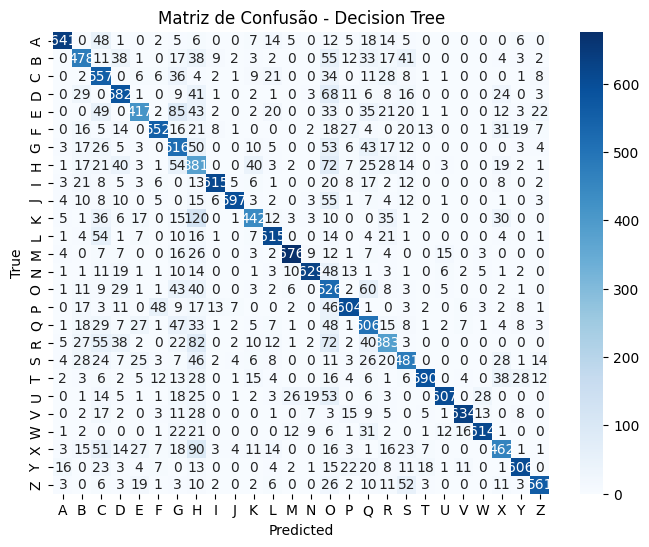

Resultados do classificador KNN
              precision    recall  f1-score   support

           A       0.99      0.99      0.99       789
           B       0.93      0.95      0.94       766
           C       0.98      0.96      0.97       736
           D       0.94      0.97      0.96       805
           E       0.95      0.95      0.95       768
           F       0.95      0.94      0.94       775
           G       0.96      0.95      0.96       773
           H       0.93      0.88      0.91       734
           I       0.96      0.96      0.96       755
           J       0.96      0.96      0.96       747
           K       0.93      0.92      0.93       739
           L       0.98      0.98      0.98       761
           M       0.99      0.98      0.98       792
           N       0.96      0.96      0.96       783
           O       0.94      0.98      0.96       753
           P       0.96      0.95      0.96       803
           Q       0.97      0.97      0.97      

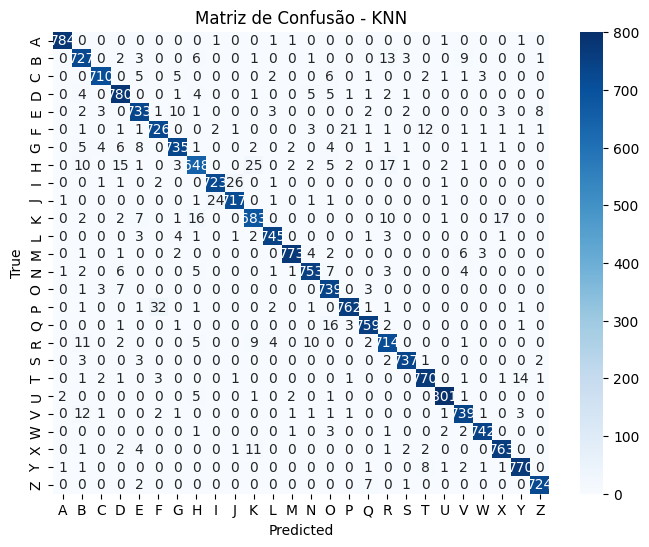

Resultados do classificador Naive Bayes
              precision    recall  f1-score   support

           A       0.84      0.87      0.85       789
           B       0.49      0.69      0.57       766
           C       0.77      0.75      0.76       736
           D       0.61      0.71      0.65       805
           E       0.60      0.36      0.45       768
           F       0.70      0.73      0.72       775
           G       0.54      0.54      0.54       773
           H       0.54      0.31      0.39       734
           I       0.53      0.77      0.63       755
           J       0.82      0.73      0.77       747
           K       0.49      0.47      0.48       739
           L       0.96      0.76      0.85       761
           M       0.65      0.89      0.75       792
           N       0.87      0.69      0.77       783
           O       0.48      0.73      0.58       753
           P       0.88      0.74      0.81       803
           Q       0.58      0.55      0.

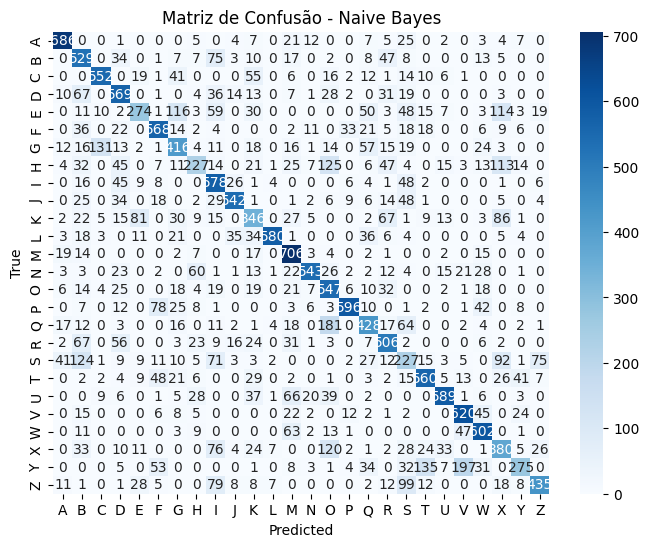

Gráfico de comparação das métricas de classificadores:


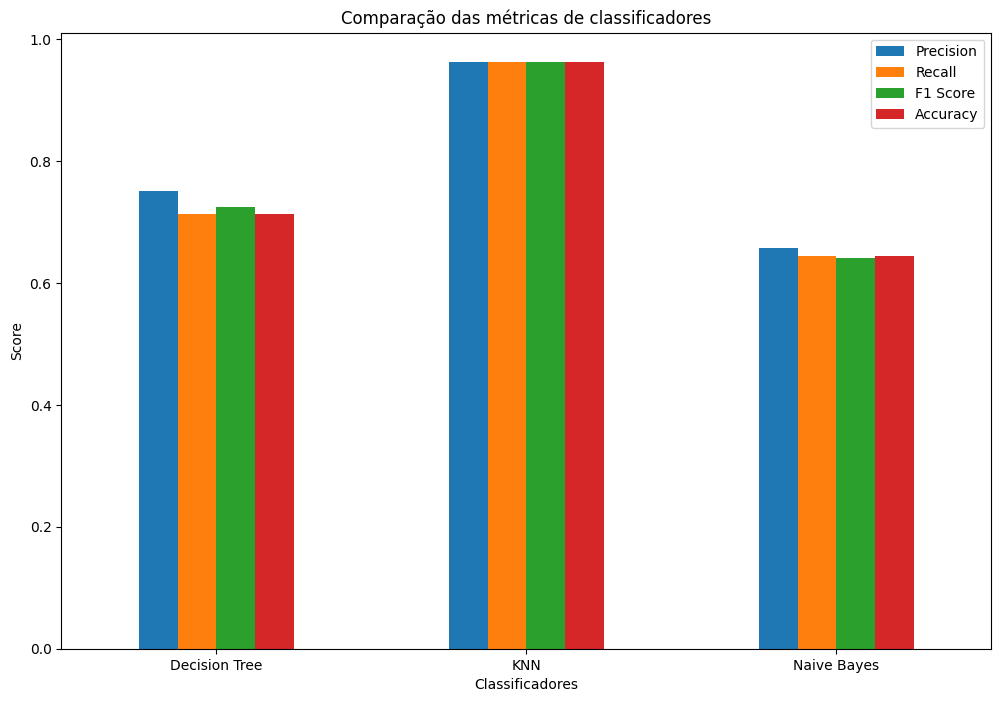

In [ ]:
for classifier in predicted_classes.keys():
  if classifier == 'knn':
    title_classifier = 'KNN'
  if classifier == 'tree':
    title_classifier = 'Decision Tree'
  if classifier == 'naive':
    title_classifier = 'Naive Bayes'
  print(f"Resultados do classificador {title_classifier}\n{metrics.classification_report(letter_targets_normalized,predicted_classes[classifier])}\n\n")
  plot_confusion_matrix(y_true=letter_targets_normalized,y_pred=predicted_classes[classifier],classifier_name=title_classifier)

metrics_dict=get_metrics_dict(letter_targets_normalized)
print("Gráfico de comparação das métricas de classificadores:")
plot_metrics(metrics_dict=metrics_dict, classifier_names=['Decision Tree', 'KNN','Naive Bayes'])

## Discussão

O classificador KNN apresentou o melhor desempenho entre os 3 analisados, com uma acurácia de 96%, seguido pelo Decision Tree com 71% e Naive Bayes com 64%. O KNN também obteve as melhores métricas de precisão, recall e F1-Score para a maioria das classes. Observou-se uma variação significativa no desempenho entre as classes para todos os classificadores. Por exemplo, classes como 'A', 'B', 'T', 'U', entre outras, geralmente apresentaram melhores métricas de precisão e recall, enquanto classes como 'H', 'S', 'X', 'Y', 'Z' tiveram desempenho inferior. Isso pode refletir a dificuldade relativa de distinguir certas letras com base nos atributos disponíveis no dataset.

# Dataset: Glass Identification
Dataset do Serviço de Ciência Forense dos EUA. Possui como classes 6 tipos de vidro definidos em termos do seu teor de óxidos (ou seja, Na, Fe, K, etc.)


## Análise exploratória
Importação do dataset Glass Identification

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
glass_identification = fetch_ucirepo(id=42)

# data (as pandas dataframes)
glass_data = glass_identification.data.features
glass_targets = glass_identification.data.targets

# metadata
print(glass_identification.metadata)

# variable information
print(glass_identification.variables)


{'uci_id': 42, 'name': 'Glass Identification', 'repository_url': 'https://archive.ics.uci.edu/dataset/42/glass+identification', 'data_url': 'https://archive.ics.uci.edu/static/public/42/data.csv', 'abstract': 'From USA Forensic Science Service; 6 types of glass; defined in terms of their oxide content (i.e. Na, Fe, K, etc)', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 214, 'num_features': 9, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Type_of_glass'], 'index_col': ['Id_number'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1987, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5WW2P', 'creators': ['B. German'], 'intro_paper': None, 'additional_info': {'summary': 'Vina conducted a comparison test of her rule-based system, BEAGLE, the nearest-neighbor algorithm, and discriminant analysis.  BEAGLE is a product available through VRS Consulting, In

In [ ]:
explore("Glass Identification",glass_data,glass_targets)

Informações sobre o dataset Glass Identification:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
dtypes: float64(9)
memory usage: 15.2 KB


None


Descrição das classes do dataset Glass Identification:



,Type_of_glass
count,214.000000
mean,2.780374
std,2.103739
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,7.000000



Descrição dos dados do dataset Glass Identification:



...

RI    178
Na    142
Mg     94
Al    118
Si    133
K      65
Ca    143
Ba     34
Fe     32
dtype: int64


Descrição dos valores distintos das classes:



Type_of_glass    6
dtype: int64


Não há valores nulos no dataset Glass Identification.

Há 1 linhas duplicadas no dataset Glass Identification:



,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type_of_glass
39,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1


Os dados possuem 6 classes (uma para cada tipo de vidro), não possuem valores nulos e possui 1 linha duplicada.

## Tratamento dos dados
Os dados são normalizados e mostrados na tabela abaixo.

In [ ]:
glass_data_normalized, glass_targets_normalized = normalize_dataset(glass_data,glass_targets)

,0,1,2,3,4,5,6,7,8,0
0,0.432836,0.437594,1.000000,0.252336,0.351786,0.009662,0.308550,0.0,0.0,1
1,0.283582,0.475188,0.801782,0.333333,0.521429,0.077295,0.223048,0.0,0.0,1
2,0.220808,0.421053,0.790646,0.389408,0.567857,0.062802,0.218401,0.0,0.0,1
3,0.285777,0.372932,0.821826,0.311526,0.500000,0.091787,0.259294,0.0,0.0,1
4,0.275241,0.381955,0.806236,0.295950,0.583929,0.088567,0.245353,0.0,0.0,1


## Aplicação dos classificadores

### Ajustando parâmetros de KNN e Decision Tree
Para o k-fold utilizado no ajuste de parâmetros, são divididos em 3 folds, e para utilização na aplicação dos modelos, 5 folds

In [ ]:
inner_kf = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=None)
outer_kf = model_selection.StratifiedKFold(n_splits=3, shuffle=True, random_state=None)

knn_best_params, decision_tree_best_params = get_best_params(glass_data_normalized,glass_targets_normalized,outer_kf,
                                                             list(np.arange(1,5)),[3,4,5,6,7,8,9,10])

Melhores parâmetros para KNN: {'n_neighbors': 1, 'weights': 'uniform'}


Melhores parâmetros para Decision Tree: {'max_depth': 6}




### Aplicando os melhores parâmetros
O dicionário python com as classes preditas é obtido e mostrado no bloco de código abaixo.

In [ ]:
predicted_classes = get_predicted_classes_str(dataset_data_normalized=glass_data_normalized,dataset_targets_normalized=glass_targets_normalized,
                                              knn_best_params=knn_best_params,decision_tree_best_params=decision_tree_best_params,
                                              inner_kf=inner_kf)
predicted_classes

{'tree': array([2, 1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1,
        1, 1, 1, 1, 2, 1, 3, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,
        3, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 3, 1, 1, 1, 1, 1, 7, 2, 1, 1, 1,
        1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 1, 2, 1, 2,
        2, 2, 1, 2, 1, 1, 2, 3, 1, 3, 2, 1, 2, 1, 1, 2, 2, 5, 7, 2, 2, 6,
        2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 3, 3, 2, 5, 6, 2, 2,
        2, 1, 1, 2, 1, 2, 2, 2, 2, 1, 1, 2, 3, 2, 1, 3, 3, 2, 2, 1, 1, 3,
        3, 1, 3, 1, 2, 3, 2, 2, 2, 7, 5, 5, 2, 5, 5, 5, 2, 5, 5, 2, 5, 5,
        2, 1, 6, 2, 6, 6, 6, 2, 1, 7, 7, 1, 3, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 2, 7, 7, 7, 7, 7, 5, 7, 7, 7, 7, 7, 7]),
 'knn': array([1, 2, 2, 2, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 3, 1, 2, 2, 1,
        3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 3, 1, 1, 3, 3, 1, 1, 1, 3,
        2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 3, 3, 1, 1, 3, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2

## Resultados
As informações de métricas e matrizes de confusão para cada classificador são mostrados no código, assim como a comparação dos classificadores.

Resultados do classificador Decision Tree
              precision    recall  f1-score   support

           1       0.65      0.73      0.69        70
           2       0.62      0.61      0.61        76
           3       0.38      0.35      0.36        17
           5       0.75      0.69      0.72        13
           6       0.67      0.44      0.53         9
           7       0.89      0.86      0.88        29

    accuracy                           0.66       214
   macro avg       0.66      0.61      0.63       214
weighted avg       0.66      0.66      0.66       214





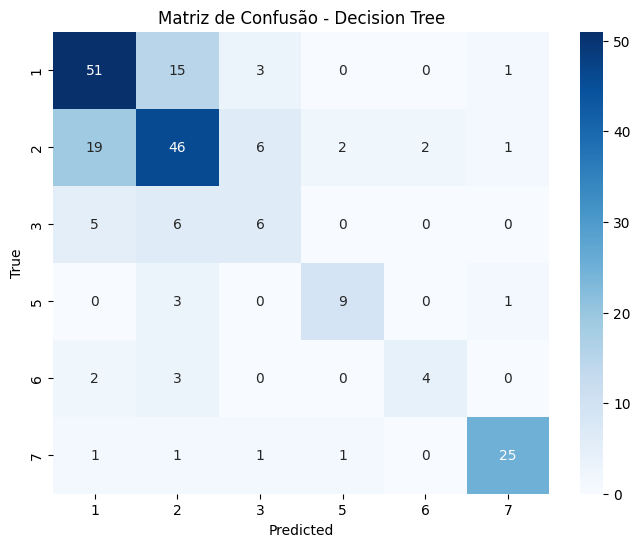

Resultados do classificador KNN
              precision    recall  f1-score   support

           1       0.68      0.73      0.70        70
           2       0.76      0.72      0.74        76
           3       0.19      0.18      0.18        17
           5       0.67      0.77      0.71        13
           6       0.60      0.67      0.63         9
           7       0.92      0.83      0.87        29

    accuracy                           0.70       214
   macro avg       0.64      0.65      0.64       214
weighted avg       0.70      0.70      0.70       214





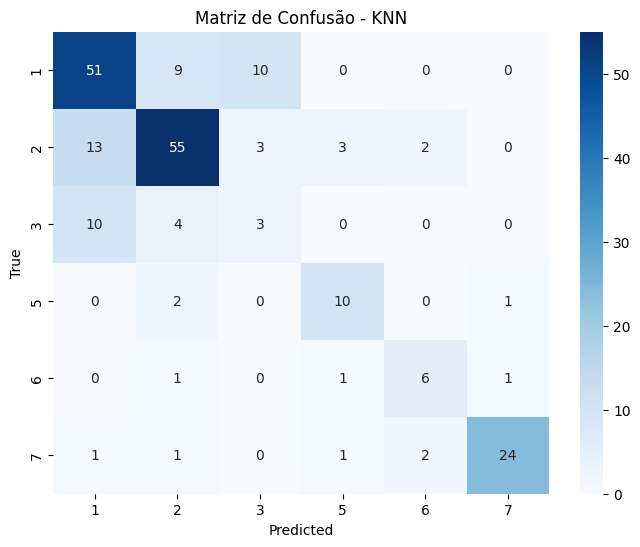

Resultados do classificador Naive Bayes
              precision    recall  f1-score   support

           1       0.48      0.57      0.52        70
           2       0.55      0.21      0.30        76
           3       0.10      0.29      0.15        17
           5       0.44      0.31      0.36        13
           6       0.62      0.89      0.73         9
           7       0.86      0.86      0.86        29

    accuracy                           0.46       214
   macro avg       0.51      0.52      0.49       214
weighted avg       0.53      0.46      0.46       214





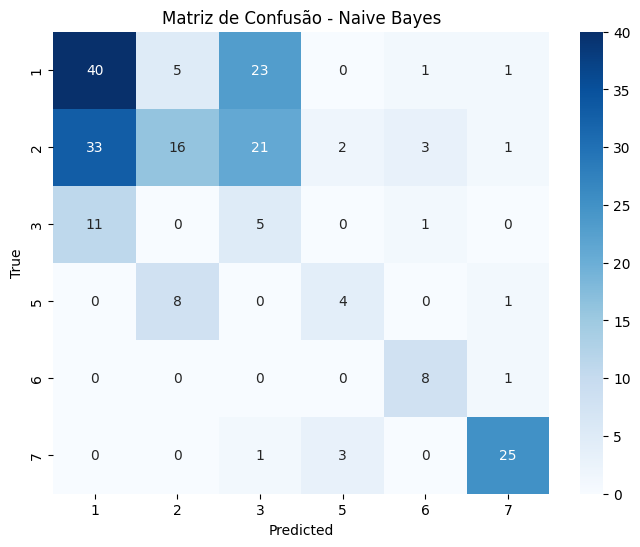

Gráfico de comparação das métricas de classificadores:


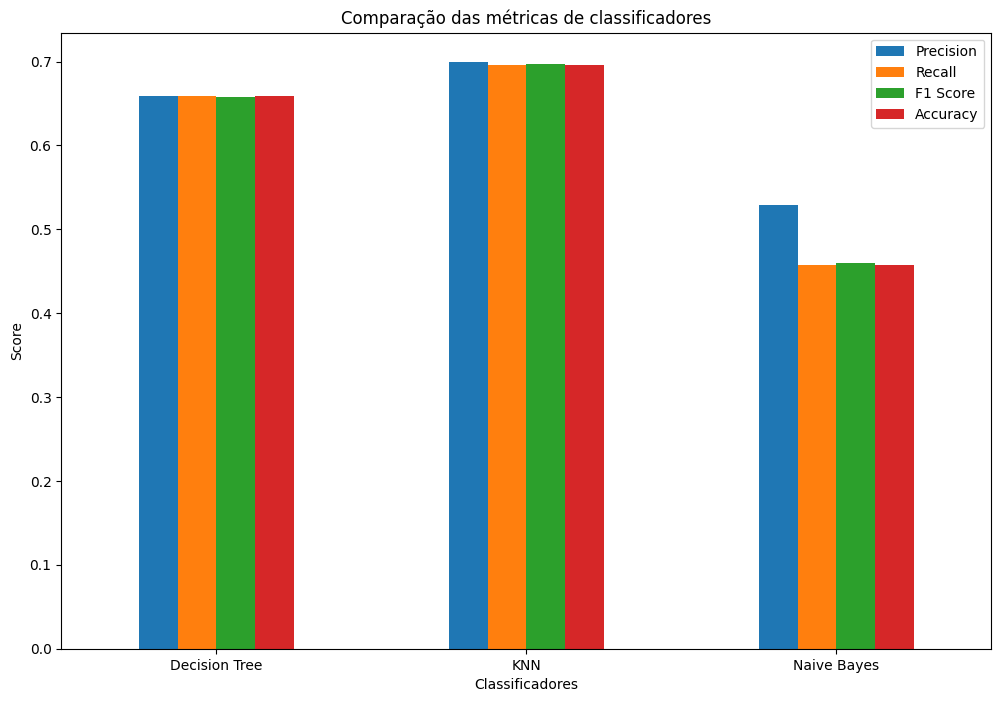

In [ ]:
for classifier in predicted_classes.keys():
  if classifier == 'knn':
    title_classifier = 'KNN'
  if classifier == 'tree':
    title_classifier = 'Decision Tree'
  if classifier == 'naive':
    title_classifier = 'Naive Bayes'
  print(f"Resultados do classificador {title_classifier}\n{metrics.classification_report(glass_targets_normalized,predicted_classes[classifier])}\n\n")
  plot_confusion_matrix(y_true=glass_targets_normalized,y_pred=predicted_classes[classifier],classifier_name=title_classifier)

metrics_dict=get_metrics_dict(glass_targets_normalized)
print("Gráfico de comparação das métricas de classificadores:")
plot_metrics(metrics_dict=metrics_dict, classifier_names=['Decision Tree', 'KNN','Naive Bayes'])

## Discussão
Com base nos resultados acima, o classificador KNN se destacou com a maior acurácia e f1-score médio, demonstrando um desempenho maior na maioria das classes. O Decision Tree apresentou um desempenho razoável, mas com variação significativa entre as classes. O Naive Bayes teve o desempenho mais fraco, indicando que pode não ser a melhor escolha para este conjunto de dados específico.